## Dataset Loaded

,Rows,Columns
0,891,12


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Dataset Overview

,Column,Dtype,Missing Values,Unique Values
0,PassengerId,int64,0,891
1,Survived,int64,0,2
2,Pclass,int64,0,3
3,Name,object,0,891
4,Sex,object,0,2
5,Age,float64,177,88
6,SibSp,int64,0,7
7,Parch,int64,0,7
8,Ticket,object,0,681
9,Fare,float64,0,248


## Descriptive Statistics

,Mean,Median,Std Dev
PassengerId,446.000000,446.0000,257.353842
Survived,0.383838,0.0000,0.486592
Pclass,2.308642,3.0000,0.836071
Age,29.699118,28.0000,14.526497
SibSp,0.523008,0.0000,1.102743
Parch,0.381594,0.0000,0.806057
Fare,32.204208,14.4542,49.693429


## Missing Values

,Column,Missing Values,Missing %
10,Cabin,687,77.10
5,Age,177,19.87
11,Embarked,2,0.22
0,PassengerId,0,0.00
1,Survived,0,0.00
2,Pclass,0,0.00
3,Name,0,0.00
4,Sex,0,0.00
6,SibSp,0,0.00
7,Parch,0,0.00


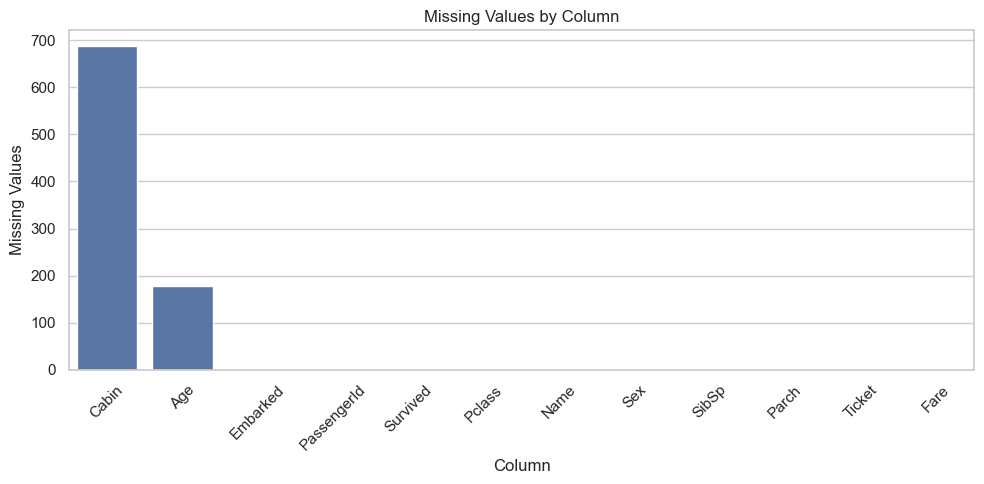

## Data Cleaning

,Column,Remaining Missing Values
0,PassengerId,0
1,Survived,0
2,Pclass,0
3,Name,0
4,Sex,0
5,Age,0
6,SibSp,0
7,Parch,0
8,Ticket,0
9,Fare,0


## Feature Engineering

,Name,Age,AgeGroup,FamilySize,IsAlone,Title,Fare,FarePerPerson
0,"Braund, Mr. Owen Harris",22.0,Adult,2,0,Mr,7.2500,3.62500
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0,Adult,2,0,Mrs,71.2833,35.64165
2,"Heikkinen, Miss. Laina",26.0,Adult,1,1,Miss,7.9250,7.92500
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.0,Adult,2,0,Mrs,53.1000,26.55000
4,"Allen, Mr. William Henry",35.0,Adult,1,1,Mr,8.0500,8.05000
5,"Moran, Mr. James",28.0,Adult,1,1,Mr,8.4583,8.45830
6,"McCarthy, Mr. Timothy J",54.0,Adult,1,1,Mr,51.8625,51.86250
7,"Palsson, Master. Gosta Leonard",2.0,Child,5,0,Master,21.0750,4.21500
8,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",27.0,Adult,3,0,Mrs,11.1333,3.71110
9,"Nasser, Mrs. Nicholas (Adele Achem)",14.0,Child,2,0,Mrs,30.0708,15.03540


## Survival Analysis

...

,AgeGroup,Survival Rate
0,Adult,0.364362
1,Child,0.539823
2,Senior,0.269231


### Top Survival by Title

,Title,Survival Rate
16,the Countess,1.000000
9,Mlle,1.000000
15,Sir,1.000000
13,Ms,1.000000
5,Lady,1.000000
10,Mme,1.000000
12,Mrs,0.792000
8,Miss,0.697802
7,Master,0.575000
1,Col,0.500000


### Survival by FamilySize

,FamilySize,Survival Rate
0,1,0.303538
1,2,0.552795
2,3,0.578431
3,4,0.724138
4,5,0.200000
5,6,0.136364
6,7,0.333333
7,8,0.000000
8,11,0.000000


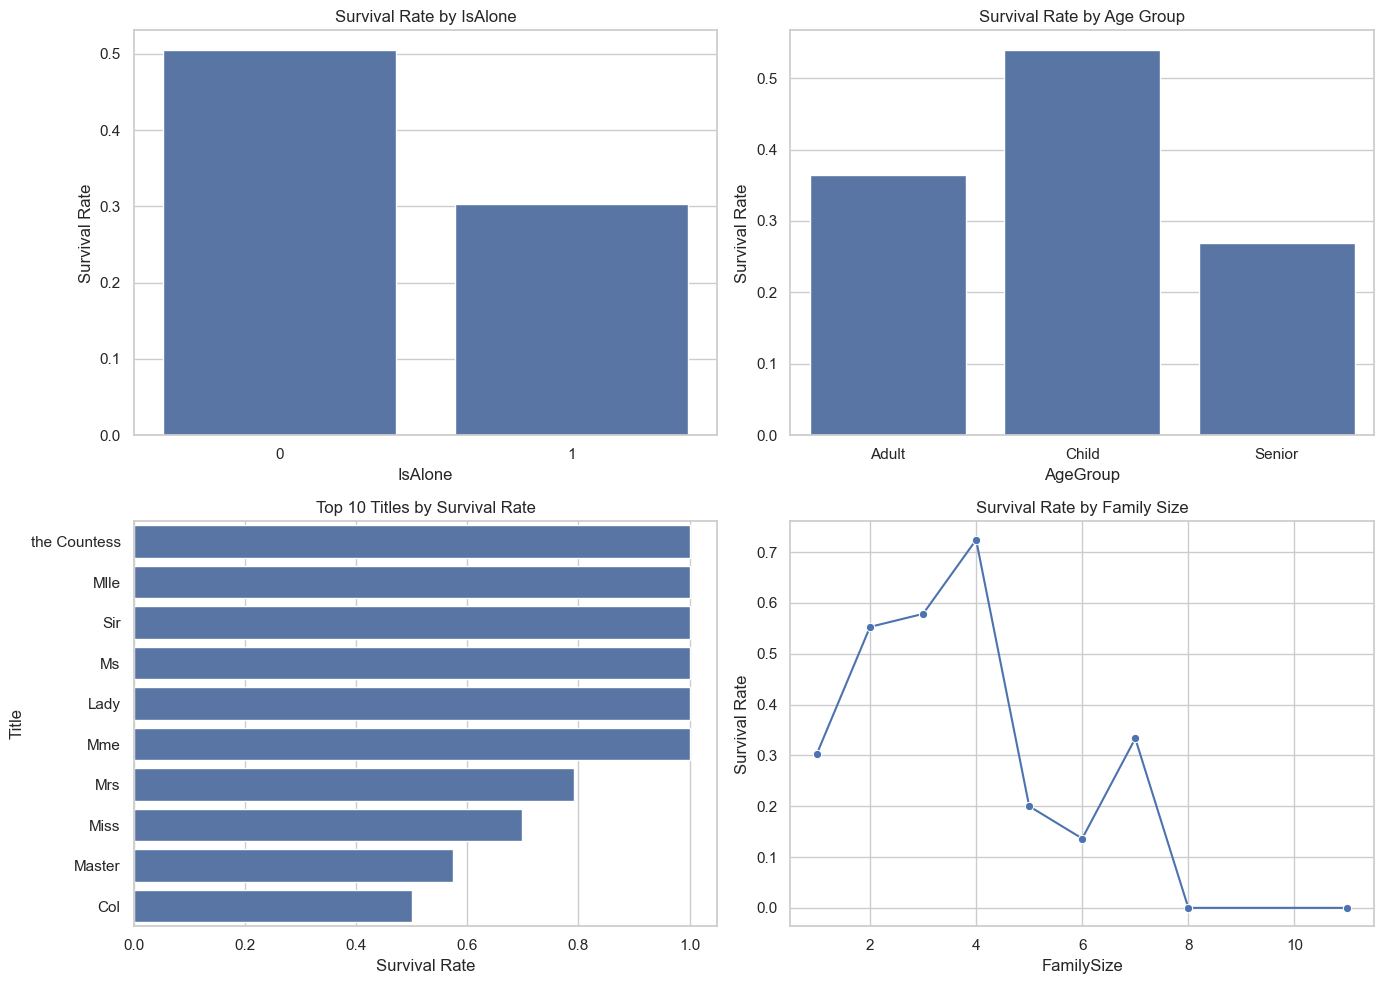

## Validation

,Check,Passed
0,Key exists: dataset_shape,True
1,Key exists: missing_values,True
2,Key exists: descriptive_statistics,True
3,Key exists: engineered_feature_analysis,True
4,Key exists: passengers,True
5,Passengers is a list,True
6,Passengers list is not empty,True


## Saved Files

,File Type,Path
0,Processed CSV,C:\Users\Adetunji\IRONHACK_LAB\Titanic_dataset...
1,Analysis JSON,C:\Users\Adetunji\IRONHACK_LAB\Titanic_dataset...


## Final Summary

,Metric,Value
0,Dataset Rows,891
1,Dataset Columns,12
2,Total Missing Values Before Cleaning,866
3,Remaining Missing Values After Cleaning,0


,IsAlone,Survival Rate
0,0,0.505650
1,1,0.303538


,AgeGroup,Survival Rate
0,Adult,0.364362
1,Child,0.539823
2,Senior,0.269231


In [5]:
import pandas as pd
import json
import numpy as np
from pathlib import Path
from dataclasses import dataclass, asdict
from typing import List, Dict, Any
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)
sns.set_theme(style="whitegrid")

# Load dataset
csv_path = Path("titanic.csv")
if not csv_path.exists():
    raise FileNotFoundError(f"File not found: {csv_path.resolve()}")

df = pd.read_csv(csv_path)

display(Markdown("## Dataset Loaded"))
display(pd.DataFrame({"Rows": [df.shape[0]], "Columns": [df.shape[1]]}))
display(df.head())

# Overview
display(Markdown("## Dataset Overview"))
overview = pd.DataFrame({
    "Column": df.columns,
    "Dtype": df.dtypes.astype(str).values,
    "Missing Values": df.isnull().sum().values,
    "Unique Values": df.nunique().values
})
display(overview)

# Descriptive statistics
display(Markdown("## Descriptive Statistics"))
numerical_columns = df.select_dtypes(include=["number"]).columns.tolist()

stats_summary_df = df[numerical_columns].agg(["mean", "median", "std"]).T
stats_summary_df.columns = ["Mean", "Median", "Std Dev"]
display(stats_summary_df)

stats_summary = {
    col: {
        "mean": float(df[col].mean()) if pd.notnull(df[col].mean()) else 0.0,
        "median": float(df[col].median()) if pd.notnull(df[col].median()) else 0.0,
        "std_dev": float(df[col].std()) if pd.notnull(df[col].std()) else 0.0
    }
    for col in numerical_columns
}

# Missing values
display(Markdown("## Missing Values"))
missing_df = pd.DataFrame({
    "Column": df.columns,
    "Missing Values": df.isnull().sum().values,
    "Missing %": ((df.isnull().sum() / len(df)) * 100).round(2).values
}).sort_values(by="Missing Values", ascending=False)
display(missing_df)

total_missing = int(df.isnull().sum().sum())
missing_values = {str(k): int(v) for k, v in df.isnull().sum().items()}

plt.figure(figsize=(10, 5))
sns.barplot(data=missing_df, x="Column", y="Missing Values")
plt.xticks(rotation=45)
plt.title("Missing Values by Column")
plt.tight_layout()
plt.show()

# Cleaning
display(Markdown("## Data Cleaning"))
df_clean = df.copy()
df_clean["Age"] = df_clean["Age"].fillna(df_clean["Age"].median())
df_clean["Cabin"] = df_clean["Cabin"].fillna("Unknown")
embarked_mode = df_clean["Embarked"].mode()
df_clean["Embarked"] = df_clean["Embarked"].fillna(embarked_mode[0] if not embarked_mode.empty else "S")

cleaning_summary = pd.DataFrame({
    "Column": df_clean.columns,
    "Remaining Missing Values": df_clean.isnull().sum().values
}).sort_values(by="Remaining Missing Values", ascending=False)
display(cleaning_summary)

# Feature engineering
display(Markdown("## Feature Engineering"))
df_clean["FamilySize"] = df_clean["SibSp"] + df_clean["Parch"] + 1
df_clean["IsAlone"] = (df_clean["FamilySize"] == 1).astype(int)
df_clean["Title"] = df_clean["Name"].str.extract(r",\s*([^\.]+)\.", expand=False)
df_clean["FarePerPerson"] = df_clean["Fare"] / df_clean["FamilySize"]

def age_group(age):
    if age < 18:
        return "Child"
    elif age < 60:
        return "Adult"
    else:
        return "Senior"

df_clean["AgeGroup"] = df_clean["Age"].apply(age_group)

display(df_clean[["Name", "Age", "AgeGroup", "FamilySize", "IsAlone", "Title", "Fare", "FarePerPerson"]].head(10))

# Survival analysis
display(Markdown("## Survival Analysis"))

survival_by_isalone_df = df_clean.groupby("IsAlone", as_index=False)["Survived"].mean().rename(columns={"Survived": "Survival Rate"})
survival_by_agegroup_df = df_clean.groupby("AgeGroup", as_index=False)["Survived"].mean().rename(columns={"Survived": "Survival Rate"})
survival_by_title_df = df_clean.groupby("Title", as_index=False)["Survived"].mean().rename(columns={"Survived": "Survival Rate"}).sort_values(by="Survival Rate", ascending=False)
survival_by_familysize_df = df_clean.groupby("FamilySize", as_index=False)["Survived"].mean().rename(columns={"Survived": "Survival Rate"})

display(Markdown("### Survival by IsAlone"))
display(survival_by_isalone_df)

display(Markdown("### Survival by AgeGroup"))
display(survival_by_agegroup_df)

display(Markdown("### Top Survival by Title"))
display(survival_by_title_df.head(10))

display(Markdown("### Survival by FamilySize"))
display(survival_by_familysize_df)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
sns.barplot(data=survival_by_isalone_df, x="IsAlone", y="Survival Rate", ax=axes[0, 0])
axes[0, 0].set_title("Survival Rate by IsAlone")

sns.barplot(data=survival_by_agegroup_df, x="AgeGroup", y="Survival Rate", ax=axes[0, 1])
axes[0, 1].set_title("Survival Rate by Age Group")

sns.barplot(data=survival_by_title_df.head(10), x="Survival Rate", y="Title", ax=axes[1, 0])
axes[1, 0].set_title("Top 10 Titles by Survival Rate")

sns.lineplot(data=survival_by_familysize_df, x="FamilySize", y="Survival Rate", marker="o", ax=axes[1, 1])
axes[1, 1].set_title("Survival Rate by Family Size")

plt.tight_layout()
plt.show()

# Export analysis dicts
survival_by_isalone = {int(k): float(v) for k, v in df_clean.groupby("IsAlone")["Survived"].mean().items()}
survival_by_agegroup = {str(k): float(v) for k, v in df_clean.groupby("AgeGroup")["Survived"].mean().items()}
survival_by_title = {str(k): float(v) for k, v in df_clean.groupby("Title")["Survived"].mean().sort_values(ascending=False).head(10).items()}
survival_by_familysize = {int(k): float(v) for k, v in df_clean.groupby("FamilySize")["Survived"].mean().items()}

analysis_results = {
    "survival_by_isalone": survival_by_isalone,
    "survival_by_agegroup": survival_by_agegroup,
    "top_survival_by_title": survival_by_title,
    "survival_by_familysize": survival_by_familysize
}

@dataclass
class PassengerRecord:
    PassengerId: int
    Survived: int
    Pclass: int
    Name: str
    Sex: str
    Age: float
    SibSp: int
    Parch: int
    Ticket: str
    Fare: float
    Cabin: str
    Embarked: str
    FamilySize: int
    IsAlone: int
    Title: str
    FarePerPerson: float
    AgeGroup: str

@dataclass
class TitanicAnalysisExport:
    dataset_shape: Dict[str, int]
    missing_values: Dict[str, int]
    descriptive_statistics: Dict[str, Dict[str, float]]
    engineered_feature_analysis: Dict[str, Dict[Any, float]]
    passengers: List[Dict[str, Any]]

passenger_records = []
for _, row in df_clean.iterrows():
    passenger = PassengerRecord(
        PassengerId=int(row["PassengerId"]),
        Survived=int(row["Survived"]),
        Pclass=int(row["Pclass"]),
        Name=str(row["Name"]),
        Sex=str(row["Sex"]),
        Age=float(row["Age"]),
        SibSp=int(row["SibSp"]),
        Parch=int(row["Parch"]),
        Ticket=str(row["Ticket"]),
        Fare=float(row["Fare"]),
        Cabin=str(row["Cabin"]),
        Embarked=str(row["Embarked"]),
        FamilySize=int(row["FamilySize"]),
        IsAlone=int(row["IsAlone"]),
        Title=str(row["Title"]),
        FarePerPerson=float(row["FarePerPerson"]),
        AgeGroup=str(row["AgeGroup"])
    )
    passenger_records.append(asdict(passenger))

export_data = TitanicAnalysisExport(
    dataset_shape={"rows": int(df_clean.shape[0]), "columns": int(df_clean.shape[1])},
    missing_values=missing_values,
    descriptive_statistics=stats_summary,
    engineered_feature_analysis=analysis_results,
    passengers=passenger_records
)

json_output = asdict(export_data)

# Validation
required_keys = [
    "dataset_shape",
    "missing_values",
    "descriptive_statistics",
    "engineered_feature_analysis",
    "passengers"
]

validation_results = []
for key in required_keys:
    validation_results.append({"Check": f"Key exists: {key}", "Passed": key in json_output})

validation_results.append({"Check": "Passengers is a list", "Passed": isinstance(json_output["passengers"], list)})
validation_results.append({"Check": "Passengers list is not empty", "Passed": len(json_output["passengers"]) > 0})

validation_df = pd.DataFrame(validation_results)
display(Markdown("## Validation"))
display(validation_df)

# Save files
output_dir = Path("output")
output_dir.mkdir(exist_ok=True)

processed_csv_path = output_dir / "titanic_processed.csv"
json_path = output_dir / "titanic_analysis.json"

df_clean.to_csv(processed_csv_path, index=False)
with open(json_path, "w", encoding="utf-8") as f:
    json.dump(json_output, f, indent=4)

display(Markdown("## Saved Files"))
display(pd.DataFrame({
    "File Type": ["Processed CSV", "Analysis JSON"],
    "Path": [str(processed_csv_path.resolve()), str(json_path.resolve())]
}))

display(Markdown("## Final Summary"))
summary_df = pd.DataFrame({
    "Metric": [
        "Dataset Rows",
        "Dataset Columns",
        "Total Missing Values Before Cleaning",
        "Remaining Missing Values After Cleaning"
    ],
    "Value": [
        df.shape[0],
        df.shape[1],
        total_missing,
        int(df_clean.isnull().sum().sum())
    ]
})
display(summary_df)
display(survival_by_isalone_df)
display(survival_by_agegroup_df)